In [ ]:
calitatea procesului de recunoastere a textului, atat la nivel de caracter, cat si la nivel de cuvant
a. prin folosirea unei metrici de distanta sau
b. prin folosirea mai multor metrici de distanta.

In [3]:
!pip install azure-cognitiveservices-vision-computervision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.9/198.9 kB 4.0 MB/s eta 0:00:00a 0:00:01


In [6]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time
'''
Authenticate
Authenticates your credentials and creates a client.
'''
subscription_key ="CCUp8BHiZaUU4sX0T28lXKFydNIdAiWKNP2QMi9PAQ3dJZaL2rc0JQQJ99BCAC5RqLJXJ3w3AAAFACOGHHIb"
endpoint = "https://numenou.cognitiveservices.azure.com/"
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

'\nEND - Authenticate\n'

In [124]:
# img = open("test1.png", "rb")
img = open("test2.jpeg", "rb")
read_response = computervision_client.read_in_stream(
    image=img,
    mode="Printed",
    raw=True
)
# print(read_response.as_dict())

operation_id = read_response.headers['Operation-Location'].split('/')[-1]
while True:
    read_result = computervision_client.get_read_result(operation_id)
    if read_result.status not in ['notStarted', 'running']:
        break
    time.sleep(1)


result = []
if read_result.status == OperationStatusCodes.succeeded:
    for text_result in read_result.analyze_result.read_results:
        for line in text_result.lines:
            print(line.text)
            result.append(line.text)

print()

Lucces in resolvarea
TEMELOR la
LABORA toarele de
Inteligenta Artificialà!



In [9]:
groundTruth = ["Succes in rezolvarea", "tEMELOR la", "LABORAtoarele de", "Inteligenta Artificiala!"]

# compute the performance
noOfCorrectLines = sum(i == j for i, j in zip(result, groundTruth))
print(noOfCorrectLines)

0


In [11]:
!pip install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 1.7 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 14.4 MB/s eta 0:00:0000:0100:01


In [128]:
from Levenshtein import distance, jaro_winkler, hamming

textResult=""
for r in result:
    textResult+=r
textGroundTruth="Succes in rezolvareatEMELOR laLABORAtoarele deInteligenta Artificiala!"

cer=distance(textResult,textGroundTruth)/len(textGroundTruth)
print("CER: ",cer)
print(textResult)
print(textGroundTruth)
print("Distanta Levenshtein: ",distance(textResult,textGroundTruth)," (numarul minim de operatii pt a transforma sirul la cel corect)")
print("Distanta Hamming: ",hamming(textResult,textGroundTruth)," (numarul de pozitii in care sirurile difera)")
print("Distanta Jaro-Winkler: ",jaro_winkler(textResult,textGroundTruth), "(asemanarea fonetica si pozitionala)\n")


wer=sum(distance(w1,w2) for w1,w2 in zip(wordsResult,wordsGroundTruth))/9
print("WER: ",wer)
wordsResult=[]
for r in result:
    s=r.split(" ")
    wordsResult+=s
print(wordsResult)
wordsGroundTruth=["Succes",  "in", "rezolvarea","tEMELOR", "la","LABORAtoarele", "de","Inteligenta" ,"Artificiala!"]
print("Distanta Levenshtein: ",sum(distance(w1,w2) for w1,w2 in zip(wordsResult,wordsGroundTruth)))
print("Distanta Hamming: ",sum(hamming(w1,w2) for w1,w2 in zip(wordsResult,wordsGroundTruth)))
print("Distanta Jaro-Winkler: ",sum(jaro_winkler(w1,w2) for w1,w2 in zip(wordsResult,wordsGroundTruth)))


CER:  0.07142857142857142
Lucces in resolvareaTEMELOR laLABORA toarele deInteligenta Artificialà!
Succes in rezolvareatEMELOR laLABORAtoarele deInteligenta Artificiala!
Distanta Levenshtein:  5  (numarul minim de operatii pt a transforma sirul la cel corect)
Distanta Hamming:  38  (numarul de pozitii in care sirurile difera)
Distanta Jaro-Winkler:  0.8918216368920593 (asemanarea fonetica si pozitionala)

WER:  3.888888888888889
['Lucces', 'in', 'resolvarea', 'TEMELOR', 'la', 'LABORA', 'toarele', 'de', 'Inteligenta', 'Artificialà!']
Distanta Levenshtein:  35
Distanta Hamming:  37
Distanta Jaro-Winkler:  6.6452514152514155


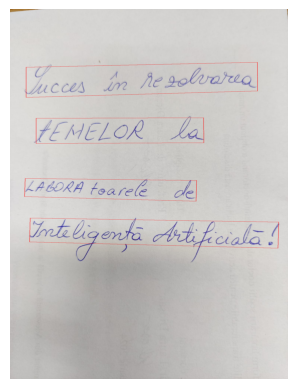

0.8649735153347448
0.901986812298902
0.8629466300913227
0.6596844329997085


In [56]:
import numpy as np
from PIL import Image,ImageDraw
import matplotlib.pyplot as plt

image = Image.open("test2.jpeg")
draw = ImageDraw.Draw(image)

groundBox=[[ 64.0,298.0, 1338.0, 466.0],[ 111.0, 579.0, 1048.0, 725.0],[80.0, 921.0, 992.0, 1030.0],[109.0,1131.0,  1456.0, 1373.0]]
def get_rect_from_bbox(bbox):
        x_min = min(bbox[::2])  
        y_min = min(bbox[1::2])
        x_max = max(bbox[::2])
        y_max = max(bbox[1::2])
        return x_min, y_min, x_max, y_max


boxing=[]
if read_result.status == OperationStatusCodes.succeeded:
    for text_result in read_result.analyze_result.read_results:
        for line in text_result.lines:
            
            bounding_box = line.bounding_box
            boxing.append(get_rect_from_bbox(bounding_box))
            
            x1, y1, x2, y2, x3, y3, x4, y4 = bounding_box
            
            
            draw.polygon([(x1, y1), (x2, y2), (x3, y3), (x4, y4)], outline="red", width=2)

image.save("output_with_boxes_pillow.jpg")
plt.imshow(image)
plt.axis("off")  
plt.show()

for i in range(len(groundBox)):
    rect_detected=boxing[i]
    rect_ground_truth=groundBox[i]
    x_min_intersection = max(rect_detected[0], rect_ground_truth[0])
    y_min_intersection = max(rect_detected[1], rect_ground_truth[1])
    x_max_intersection = min(rect_detected[2], rect_ground_truth[2])
    y_max_intersection = min(rect_detected[3], rect_ground_truth[3])
    if x_min_intersection < x_max_intersection and y_min_intersection < y_max_intersection:
        intersection_area = (x_max_intersection - x_min_intersection) * (y_max_intersection - y_min_intersection)
    else:
        intersection_area = 0
    
    
    area_detected = (rect_detected[2] - rect_detected[0]) * (rect_detected[3] - rect_detected[1])
    area_ground_truth = (rect_ground_truth[2] - rect_ground_truth[0]) * (rect_ground_truth[3] - rect_ground_truth[1])

   
    iou = intersection_area / (area_detected + area_ground_truth - intersection_area)
    print(iou)

In [ ]:
posibilitati de imbunatatire a recunoasterii textului

In [121]:
from PIL import Image, ImageEnhance, ImageFilter,ImageOps
from spellchecker import SpellChecker
from symspellpy import SymSpell

image=Image.open("test2.jpeg")

image=image.resize((800,800))

enhancer=ImageEnhance.Contrast(image)
image=enhancer.enhance(6)
image = ImageOps.equalize(image)


image.save("processed_image.jpg")


img = open("processed_image.jpg", "rb")
read_response = computervision_client.read_in_stream(
    image=img,
    mode="Printed",
    raw=True
)
# print(read_response.as_dict())

operation_id = read_response.headers['Operation-Location'].split('/')[-1]
while True:
    read_result = computervision_client.get_read_result(operation_id)
    if read_result.status not in ['notStarted', 'running']:
        break
    time.sleep(1)

# Print the detected text, line by line
result = []
if read_result.status == OperationStatusCodes.succeeded:
    for text_result in read_result.analyze_result.read_results:
        for line in text_result.lines:
            print(line.text)
            result.append(line.text)

print()

textResult=""
for r in result:
    textResult+=r
textGroundTruth="Succes in rezolvareatEMELOR laLABORAtoarele deInteligenta Artificiala!"

print(textResult)
print(textGroundTruth)
print("Distanta Levenshtein: ",distance(textResult,textGroundTruth)," (numarul minim de operatii pt a transforma sirul la cel corect)")
print("Distanta Hamming: ",hamming(textResult,textGroundTruth)," (numarul de pozitii in care sirurile difera)")
print("Distanta Jaro-Winkler: ",jaro_winkler(textResult,textGroundTruth), "(asemanarea fonetica si pozitionala)\n")


wordsResult=[]
for r in result:
    s=r.split(" ")
    wordsResult+=s
print(wordsResult)
wordsGroundTruth=["Succes",  "in", "rezolvarea","tEMELOR", "la","LABORAtoarele", "de","Inteligenta" ,"Artificiala!"]
print("Distanta Levenshtein: ",sum(distance(w1,w2) for w1,w2 in zip(wordsResult,wordsGroundTruth)))
print("Distanta Hamming: ",sum(hamming(w1,w2) for w1,w2 in zip(wordsResult,wordsGroundTruth)))
print("Distanta Jaro-Winkler: ",sum(jaro_winkler(w1,w2) for w1,w2 in zip(wordsResult,wordsGroundTruth)))



Succes in resolvarea
TEMELOR la
LABORA toarele de
Inteligenta Artificialà!

CER

Succes in resolvareaTEMELOR laLABORA toarele deInteligenta Artificialà!
Succes in rezolvareatEMELOR laLABORAtoarele deInteligenta Artificiala!
Distanta Levenshtein:  4  (numarul minim de operatii pt a transforma sirul la cel corect)
Distanta Hamming:  37  (numarul de pozitii in care sirurile difera)
Distanta Jaro-Winkler:  0.9532952941529775 (asemanarea fonetica si pozitionala)

WER

['Succes', 'in', 'resolvarea', 'TEMELOR', 'la', 'LABORA', 'toarele', 'de', 'Inteligenta', 'Artificialà!']
Distanta Levenshtein:  34
Distanta Hamming:  36
Distanta Jaro-Winkler:  6.756362526362526


In [ ]:
Lucces in resolvarea
TEMELOR la
LABORA toarele de
Inteligenta Artificialà!


In [93]:
pip install symspellpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 11.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 6.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


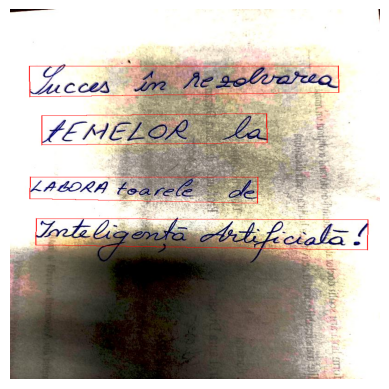

0.8713121118012422
0.9402967905211089
0.9257999583535781
0.6508067689885871


In [122]:

image = Image.open("processed_image.jpg")
draw = ImageDraw.Draw(image)

groundBox=[[ 37.0,114.0, 715.0, 189.0],[ 66.0, 227.0, 563.0, 295.0],[41.0, 362.0, 538.0, 416.0],[51.0,448.0, 777.0, 553.0]]
def get_rect_from_bbox(bbox):
        x_min = min(bbox[::2])  
        y_min = min(bbox[1::2])
        x_max = max(bbox[::2])
        y_max = max(bbox[1::2])
        return x_min, y_min, x_max, y_max


boxing=[]
if read_result.status == OperationStatusCodes.succeeded:
    for text_result in read_result.analyze_result.read_results:
        for line in text_result.lines:
            
            bounding_box = line.bounding_box
            boxing.append(get_rect_from_bbox(bounding_box))
            
            x1, y1, x2, y2, x3, y3, x4, y4 = bounding_box
            
            
            draw.polygon([(x1, y1), (x2, y2), (x3, y3), (x4, y4)], outline="red", width=2)

image.save("output_with_boxes_pillow2.jpg")
plt.imshow(image)
plt.axis("off")  
plt.show()

for i in range(len(groundBox)):
    rect_detected=boxing[i]
    rect_ground_truth=groundBox[i]
    x_min_intersection = max(rect_detected[0], rect_ground_truth[0])
    y_min_intersection = max(rect_detected[1], rect_ground_truth[1])
    x_max_intersection = min(rect_detected[2], rect_ground_truth[2])
    y_max_intersection = min(rect_detected[3], rect_ground_truth[3])
    if x_min_intersection < x_max_intersection and y_min_intersection < y_max_intersection:
        intersection_area = (x_max_intersection - x_min_intersection) * (y_max_intersection - y_min_intersection)
    else:
        intersection_area = 0
    
    
    area_detected = (rect_detected[2] - rect_detected[0]) * (rect_detected[3] - rect_detected[1])
    area_ground_truth = (rect_ground_truth[2] - rect_ground_truth[0]) * (rect_ground_truth[3] - rect_ground_truth[1])

   
    iou = intersection_area / (area_detected + area_ground_truth - intersection_area)
    print(iou)
#os.remove(temp_file_path)